# Tahap 3: Visualization & Insight Communication
**Proyek:** iFood Customer & Marketing Intelligence Analysis

---

## 📌 Gambaran Umum
Fase akhir ini bertujuan untuk mentransformasikan temuan teknis dari Tahap 1 (EDA) dan Tahap 2 (Statistical Analysis) menjadi narasi bisnis yang visual dan prediktif. Fokus utama adalah mengomunikasikan wawasan (insight) kepada stakeholder non-teknis guna mengoptimalkan ROI pemasaran, meningkatkan retensi pelanggan, dan mengidentifikasi peluang pertumbuhan pendapatan melalui segmentasi yang presisi.

## 🎯 Agenda Pembelajaran (Menjawab Pertanyaan Strategis)
1. **Profil & Segmentasi:** Bagaimana distribusi pelanggan bernilai tinggi (*Gold Spender*) berdasarkan tingkat pendapatan (*Income Tier*)?
2. **Efektivitas Kampanye:** Bagaimana alur konversi dari Kampanye 1 hingga kampanye terakhir (*Response*)?
3. **Analisis Churn & Perilaku:** Apakah pelanggan yang berisiko *churn* masih aktif berinteraksi di saluran digital (Web Visits)?
4. **Atribusi Saluran:** Saluran mana yang memberikan kontribusi volume transaksi terbesar bagi perusahaan?
5. **Sensitivitas Harga:** Apakah kelompok pelanggan tertentu lebih responsif terhadap diskon dibandingkan yang lain?
6. **Optimasi Bauran Produk:** Kategori produk apa yang memiliki korelasi kuat untuk strategi *bundling* atau *cross-selling*?
7. **Faktor Pendorong Utama:** Variabel apa saja (seperti *Income* atau *Kids*) yang secara signifikan memengaruhi pendapatan menurut model regresi?

## 🛠️ Metodologi Visualisasi
- **Dashboard Eksekutif:** Ringkasan KPI utama (Revenue, AOV, Conversion Rate) menggunakan *Plotly Indicators*.
- **Deep Dive Analysis:** Visualisasi interaktif menggunakan *Scatter Plots*, *Boxplots*, dan *Grouped Bar Charts* untuk membedah perilaku segmen.
- **Marketing Funnel:** Melacak efisiensi promosi menggunakan *Funnel Charts* untuk mengidentifikasi titik *drop-off* pelanggan.
- **Matrix & Hierarchy:** Menggunakan *Treemaps* untuk kontribusi produk dan *Heatmaps* untuk korelasi antar variabel.
- **Actionable Reporting:** Setiap grafik disertai dengan kerangka **Finding-Insight-Action** untuk menjamin data dapat ditindaklanjuti secara taktis.

---

In [1]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from pathlib import Path
import os

# Pengaturan visualisasi agar konsisten dan profesional
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
plotly_template = "plotly_white"
custom_colors = px.colors.qualitative.Prism

# Konfigurasi untuk menampilkan semua kolom dan baris saat display DataFrame
pd.set_option('display.max_columns', None)

# Memuat dataset (Asumsi dataset hasil cleaning tahap 1 & 2)

# --- Konfigurasi Path ---
# Menggunakan pathlib agar 'tahan banting' di sistem operasi apa pun (Windows/Mac/Linux)
current_folder = Path.cwd() 
if current_folder.name == "notebooks":
    BASE_DIR = current_folder.parent
else:
    BASE_DIR = current_folder

# Mendefinisikan jalur ke file hasil binning
DATA_PATH = BASE_DIR / "data" / "processed" / "ifood_binned_ready.csv"

# Memuat dataset
try:
    df = pd.read_csv(DATA_PATH)

    # Menambahkan kolom kalkulasi pembantu untuk analisis lebih lanjut
    # Total pembelian dari semua channel
    df['Total_Purchases'] = df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases']
    print(f"✅ Kolom tambahan 'Total_Purchases' berhasil ditambah")

    # Mengubah format income menjadi int64
    df['Income'] = df['Income'].astype('int64')
    print(f"✅ Format kolom income berhasil diubah menjadi int 64")

    # Cek info kembali untuk memastikan perubahan tipe data
    df.info(verbose=True, show_counts=True)
    print(f"\n✅ Berhasil memuat data dari: {DATA_PATH}")
    print(f"📊 Total baris: {len(df)} | Total kolom: {len(df.columns)}")
    display(df.head())
except FileNotFoundError:
    print(f"❌ Error: File tidak ditemukan di {DATA_PATH}. Pastikan script 'data_binning.py' sudah dijalankan.")

✅ Kolom tambahan 'Total_Purchases' berhasil ditambah
✅ Format kolom income berhasil diubah menjadi int 64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2182 entries, 0 to 2181
Data columns (total 53 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Income                    2182 non-null   int64 
 1   Kidhome                   2182 non-null   int64 
 2   Teenhome                  2182 non-null   int64 
 3   Recency                   2182 non-null   int64 
 4   MntWines                  2182 non-null   int64 
 5   MntFruits                 2182 non-null   int64 
 6   MntMeatProducts           2182 non-null   int64 
 7   MntFishProducts           2182 non-null   int64 
 8   MntSweetProducts          2182 non-null   int64 
 9   MntGoldProds              2182 non-null   int64 
 10  NumDealsPurchases         2182 non-null   int64 
 11  NumWebPurchases           2182 non-null   int64 
 12  NumCatalogPurchases       

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Customer_Days,marital_Divorced,marital_Married,marital_Single,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Age_Group,Income_Tier,Churn_Risk,Customer_Value_Segment,Family_Status,Marital_Status_Label,Education_Level_Label,Tenure_Segment,Main_Product_Category,MntTotal_Calculated,Total_Campaigns_Accepted,Campaign_Engagement,First_Accepted_Campaign,Total_Purchases
0,58138,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,63,2822,0,0,1,0,0,0,0,1,0,0,1529,1441,0,Elderly (>60),Medium Income,At-Risk (31-60d),Gold Spender,No Children,Single,Graduation,Long-term Member,Wines,1617,0,Never Accepted,No Acceptance,22
1,46344,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,66,2272,0,0,1,0,0,0,0,1,0,0,21,15,0,Elderly (>60),Medium Income,At-Risk (31-60d),Bronze Spender,Large Family (>1 Kid),Single,Graduation,New Member,Wines,27,0,Never Accepted,No Acceptance,4
2,71613,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,55,2471,0,0,0,1,0,0,0,1,0,0,734,692,0,Senior (46-60),High Income,Active (0-30d),Silver Spender,No Children,Together,Graduation,Established,Wines,776,0,Never Accepted,No Acceptance,20
3,26646,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,36,2298,0,0,0,1,0,0,0,1,0,0,48,43,0,Middle-Aged (31-45),Low Income,Active (0-30d),Bronze Spender,Small Family (1 Kid),Together,Graduation,New Member,MeatProducts,53,0,Never Accepted,No Acceptance,6
4,58293,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,39,2320,0,1,0,0,0,0,0,0,0,1,407,392,0,Middle-Aged (31-45),Medium Income,Inactive (>60d),Silver Spender,Small Family (1 Kid),Married,PhD,New Member,Wines,422,0,Never Accepted,No Acceptance,14


## 📈 Part 2: Global Metrics Overview (The KPI Dashboard)
Dasbor indikator kinerja utama (KPI) yang memberikan ringkasan kesehatan bisnis secara keseluruhan.

In [2]:
# ==========================================
# CELL 4: GLOBAL METRICS OVERVIEW (KPI DASHBOARD)
# ==========================================

# 1. Kalkulasi Metrik Agregat (Business Health Indicators)
# Menghitung total transaksi dari seluruh channel pembelanjaan
total_transactions = (df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases']).sum()

# Menghitung 4 KPI Utama
total_revenue = df['MntTotal'].sum()
total_customers = len(df)
# Menghindari ZeroDivisionError jika data transaksi kosong
aov = total_revenue / total_transactions if total_transactions > 0 else 0 
overall_conversion_rate = df['Response'].mean() * 100

# 2. Membuat Visualisasi Interaktif Menggunakan Plotly
fig_kpi = go.Figure()

# Indikator 1: Total Revenue (Kesehatan Keuangan Utama)
fig_kpi.add_trace(go.Indicator(
    mode="number",
    value=total_revenue,
    number={'prefix': "$", 'valueformat': ",.0f", 'font': {'color': '#2a9d8f'}},
    title={"text": "Total Revenue (LTV Proxy)", 'font': {'size': 16, 'color': 'gray'}},
    domain={'row': 0, 'column': 0}
))

# Indikator 2: Total Customers (Ukuran Basis Pelanggan)
fig_kpi.add_trace(go.Indicator(
    mode="number",
    value=total_customers,
    number={'valueformat': ",.0f", 'font': {'color': '#264653'}},
    title={"text": "Total Unique Customers", 'font': {'size': 16, 'color': 'gray'}},
    domain={'row': 0, 'column': 1}
))

# Indikator 3: Average Order Value / AOV (Efisiensi Belanja)
fig_kpi.add_trace(go.Indicator(
    mode="number",
    value=aov,
    number={'prefix': "$", 'valueformat': ",.2f", 'font': {'color': '#e9c46a'}},
    title={"text": "Average Order Value (AOV)", 'font': {'size': 16, 'color': 'gray'}},
    domain={'row': 1, 'column': 0}
))

# Indikator 4: Global Conversion Rate (Efektivitas Kampanye Terakhir)
fig_kpi.add_trace(go.Indicator(
    mode="number",
    value=overall_conversion_rate,
    number={'suffix': "%", 'valueformat': ",.2f", 'font': {'color': '#e76f51'}},
    title={"text": "Global Conversion Rate", 'font': {'size': 16, 'color': 'gray'}},
    domain={'row': 1, 'column': 1}
))

# 3. Kustomisasi Layout agar Elegan dan Minimalis
fig_kpi.update_layout(
    grid={'rows': 2, 'columns': 2, 'pattern': "independent"},
    template="plotly_white",
    height=450,
    margin=dict(t=80, b=40, l=40, r=40),
    title={
        'text': "<b>📈 iFood Business Health Dashboard</b>",
        'y': 0.95,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 22, 'color': '#264653'}
    }
)

# Tampilkan visualisasi
fig_kpi.show()

### 💡 Executive Interpretation: Global Metrics
**Finding:** Total Revenue mencapai nilai absolut yang solid dari basis pelanggan yang ada, dengan *Average Order Value* (AOV) yang mengindikasikan setiap keranjang belanja rata-rata bernilai moderat-tinggi. Namun, *Global Conversion Rate* (tingkat penerimaan pada kampanye pemasaran terakhir/Response) berada pada persentase yang menantang (sekitar ~15%).

**Insight:** Basis pelanggan iFood sudah terbentuk dan bersedia membelanjakan uangnya (AOV sehat). Masalah (dan peluang) terbesarnya terletak pada efisiensi marketing. Angka konversi yang rendah berarti ada banyak anggaran pemasaran yang "terbuang" (*wasted ad spend*) untuk pelanggan yang tidak relevan atau penawaran yang kurang menarik.

**Business Action:** Fokus strategis kuartal depan **BUKAN** pada akuisisi pelanggan baru secara membabi buta, melainkan pada **Precision Targeting**. Tim perlu mengalihkan budget kampanye massal menuju promosi terpersonalisasi (segmentasi berbasis data) guna mendongkrak *Conversion Rate* minimal 5% tanpa perlu menambah anggaran akuisisi.

## 🕵️‍♂️ Part 3: Customer Deep Dive
 Q1: Customer Segment vs Income Tier

In [4]:
# ==========================================
# CELL 6: CUSTOMER DEEP DIVE (Q1) - KARAKTERISTIK & NILAI
# ==========================================

# 1. Membersihkan Outlier & Menyiapkan Kolom Pendukung
# Menghapus outlier Income > 150.000 agar visualisasi tidak terkompresi
df_clean = df[df['Income'] < 150000].copy()

# FIX: Membuat kolom Total_Children secara on-the-fly karena tidak ada di dataset asli
df_clean['Total_Children'] = df_clean['Kidhome'] + df_clean['Teenhome']

# 1. Membuat Interactive Scatter Plot dengan Plotly Express
# Menambahkan marginal_x dan marginal_y untuk melihat distribusi di pinggir grafik
fig_q1 = px.scatter(
    df_clean, 
    x="Income", 
    y="MntTotal", 
    color="Customer_Value_Segment",
    color_discrete_sequence=["#e76f51", "#e9c46a", "#2a9d8f"], # Bronze, Silver, Gold
    marginal_x="box", # Menambahkan boxplot di sumbu X (Atas)
    marginal_y="box", # Menambahkan boxplot di sumbu Y (Kanan)
    hover_data=["Age", "Total_Children", "Customer_Days", "NumWebVisitsMonth"], # Data tambahan saat kursor diarahkan
    opacity=0.7,
    title="<b>Customer Segmentation: Income vs Total Spending</b><br><sup>Menganalisis daya beli berdasarkan tingkat pendapatan tahunan pelanggan.</sup>"
)

# 2. Kustomisasi Layout dan Format Sumbu (Mata Uang $)
fig_q1.update_layout(
    template="plotly_white",
    height=600,
    xaxis_title="<b>Pendapatan Tahunan (Income)</b>",
    yaxis_title="<b>Total Pengeluaran (Total Spending)</b>",
    legend_title="<b>Value Segment</b>",
    font=dict(size=12, color="#264653"),
    hovermode="closest"
)

# Memformat angka di sumbu X dan Y agar menampilkan simbol Dollar ($)
fig_q1.update_xaxes(tickformat="$,.0f", showgrid=True, gridwidth=1, gridcolor='LightGray')
fig_q1.update_yaxes(tickformat="$,.0f", showgrid=True, gridwidth=1, gridcolor='LightGray')

# 3. Menampilkan Visualisasi
fig_q1.show()



# ---------------------------------------------------------
# VISUALISASI TAMBAHAN: Rata-rata Spending per Age Group
# ---------------------------------------------------------
# Agregasi data untuk bar chart
age_spending = df.groupby(['Age_Group', 'Customer_Value_Segment'])['MntTotal'].mean().reset_index()

fig_age = px.bar(
    age_spending, 
    x='Age_Group', 
    y='MntTotal', 
    color='Customer_Value_Segment',
    barmode='group',
    color_discrete_sequence=["#e76f51", "#e9c46a", "#2a9d8f"],
    title="<b>Average Spending by Age Group & Segment</b>",
    text_auto='$.0f' # Menampilkan angka di atas batang dengan format dolar
)

fig_age.update_layout(
    template="plotly_white", 
    height=400,
    xaxis_title="<b>Kelompok Usia (Age Group)</b>",
    yaxis_title="<b>Rata-rata Pengeluaran (Avg Spending)</b>"
)
fig_age.update_yaxes(tickformat="$,.0f")
fig_age.show()

### 💡 Executive Interpretation: Customer Characteristics & Value
**Finding:** Berdasarkan *Scatter Plot*, terlihat batas pemisah yang sangat jelas (korelasi positif linear) antara *Income* dan *Total Spending*. Pelanggan berpendapatan di atas $70.000 mendominasi segmen **Gold Spender** (hijau), dengan total pengeluaran tahunan antara $1.000 hingga $2.500+. Sebaliknya, mayoritas pelanggan dengan pendapatan di bawah $40.000 tertahan di segmen **Bronze Spender** (merah). Dari *Bar Chart*, kelompok usia *Middle-Aged* (31-45 tahun) dan *Senior* (46-60 tahun) adalah penyumbang rata-rata *spending* terbesar di segmen Gold.

**Insight:** Daya beli (*Purchasing Power*) murni didorong oleh tingkat pendapatan, bukan sekadar usia. Namun, kelompok *Middle-Aged* dan *Senior* memegang kendali ekonomi yang lebih stabil. Pelanggan "Bronze" bukan tidak mau membeli, melainkan terbatasi oleh kapabilitas finansial mereka (kepadatan titik terhenti di batas pengeluaran ~$100-$300).

**Business Action:** 1. **Tiered Product Strategy:** Tim Produk harus memastikan ketersediaan barang "Premium" (harga tinggi, margin tinggi) yang ditargetkan secara spesifik untuk kelompok usia 31-60 tahun dengan *Income* di atas $70k.
2. **Value-Pack untuk Segmen Bawah:** Untuk segmen *Bronze* dengan *Income* < $40k, hindari mempromosikan barang premium satuan. Alihkan strategi penawaran ke *Bundle Pack* atau produk berukuran ekonomis (*affordable essentials*) untuk menstimulasi volume transaksi dari kelompok ini.

In [5]:
# ==========================================
# CELL 8: CUSTOMER DEEP DIVE (Q3) - CHURN RISK & BEHAVIOR
# ==========================================

# 1. Mengurutkan kategori Churn_Risk agar tampil logis di grafik
# (Sesuai dengan hasil binning: Active -> At-Risk -> Inactive)
churn_order = ['Active (0-30d)', 'At-Risk (31-60d)', 'Inactive (>60d)']
df['Churn_Risk'] = pd.Categorical(df['Churn_Risk'], categories=churn_order, ordered=True)

# Menentukan palet warna profesional untuk status risiko
# Active (Hijau), At-Risk (Kuning), Inactive (Merah)
color_map = {'Active (0-30d)': '#2a9d8f', 'At-Risk (31-60d)': '#e9c46a', 'Inactive (>60d)': '#e76f51'}

# 2. Membuat Subplots (1 Baris, 2 Kolom)
fig_q3 = make_subplots(
    rows=1, cols=2, 
    subplot_titles=("<b>Total Pengeluaran per Segmen Churn</b>", "<b>Kunjungan Web Bulanan per Segmen Churn</b>"),
    horizontal_spacing=0.15
)

# 3. Looping untuk memasukkan data ke dalam masing-masing subplot
for churn_status in churn_order:
    df_filtered = df[df['Churn_Risk'] == churn_status]
    
    # Plot Kiri: MntTotal vs Churn_Risk
    fig_q3.add_trace(
        go.Box(
            y=df_filtered['MntTotal'], 
            name=churn_status, 
            marker_color=color_map[churn_status],
            boxpoints='outliers', # Hanya menampilkan titik outlier agar lebih bersih
            showlegend=False
        ),
        row=1, col=1
    )
    
    # Plot Kanan: NumWebVisitsMonth vs Churn_Risk
    fig_q3.add_trace(
        go.Box(
            y=df_filtered['NumWebVisitsMonth'], 
            name=churn_status, 
            marker_color=color_map[churn_status],
            boxpoints='outliers',
            showlegend=False
        ),
        row=1, col=2
    )

# 4. Kustomisasi Layout dan Format Sumbu
fig_q3.update_layout(
    template="plotly_white",
    height=500,
    title={
        'text': "<b>Analisis Risiko Churn: Dampak Recency pada Revenue & Engagement</b>",
        'y': 0.95,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 20, 'color': '#264653'}
    },
    font=dict(size=12, color="#264653"),
    margin=dict(t=80, b=40, l=40, r=40)
)

# Memformat sumbu Y pada Plot Kiri (MntTotal) dengan simbol Dollar ($)
fig_q3.update_yaxes(title_text="Total Spending", tickformat="$,.0f", row=1, col=1, showgrid=True, gridcolor='LightGray')

# Memformat sumbu Y pada Plot Kanan (Web Visits) dengan angka biasa
fig_q3.update_yaxes(title_text="Web Visits / Month", row=1, col=2, showgrid=True, gridcolor='LightGray')
fig_q3.update_xaxes(title_text="Churn Risk Segment", row=1, col=1)
fig_q3.update_xaxes(title_text="Churn Risk Segment", row=1, col=2)

# Tampilkan visualisasi
fig_q3.show()

### 💡 Executive Interpretation: Churn Risk & Engagement Behavior
**Finding:** Grafik sebelah kiri menunjukkan bahwa nilai *Total Spending* ($) mengalami penurunan seiring dengan meningkatnya status *Churn Risk* (Pelanggan 'Active' membelanjakan uang jauh lebih banyak dibanding 'Inactive'). Namun, fakta menarik terlihat pada grafik sebelah kanan: rata-rata **Kunjungan Web Bulanan (Web Visits) justru tetap stabil atau bahkan sedikit lebih tinggi** pada kelompok 'At-Risk' dan 'Inactive' (median berkisar di 6-7 kunjungan per bulan).

**Insight:** Tingginya *Recency* (sudah lama tidak beli / Inactive) ternyata **bukan disebabkan oleh hilangnya minat**. Mereka masih secara aktif mengunjungi website iFood (melakukan *window shopping* atau mengecek harga), tetapi mereka tidak melakukan *checkout*. Ini mengindikasikan adanya friksi kuat di tahap akhir corong pembelian (*bottom of the funnel*), seperti harga yang dirasa terlalu mahal, ketiadaan promo yang relevan, atau biaya pengiriman yang tidak sepadan.

**Business Action:** 1. **Triggered Retargeting:** Karena mereka masih mengunjungi web, terapkan program "Win-Back" otomatis. Jika sistem mendeteksi pelanggan 'At-Risk' login ke web namun tidak *checkout* dalam 2 jam, kirimkan *Push Notification* atau Email berisi kupon **"Diskon Spesial 15% Berlaku Hari Ini Saja"**.
2. **Abandoned Cart Audit:** Tim UI/UX dan Marketing perlu menginvestigasi alur *checkout* di *Web Channel* untuk melihat apakah ada *hidden cost* (biaya tersembunyi seperti ongkir mahal) yang membatalkan niat beli para pengunjung setia ini.

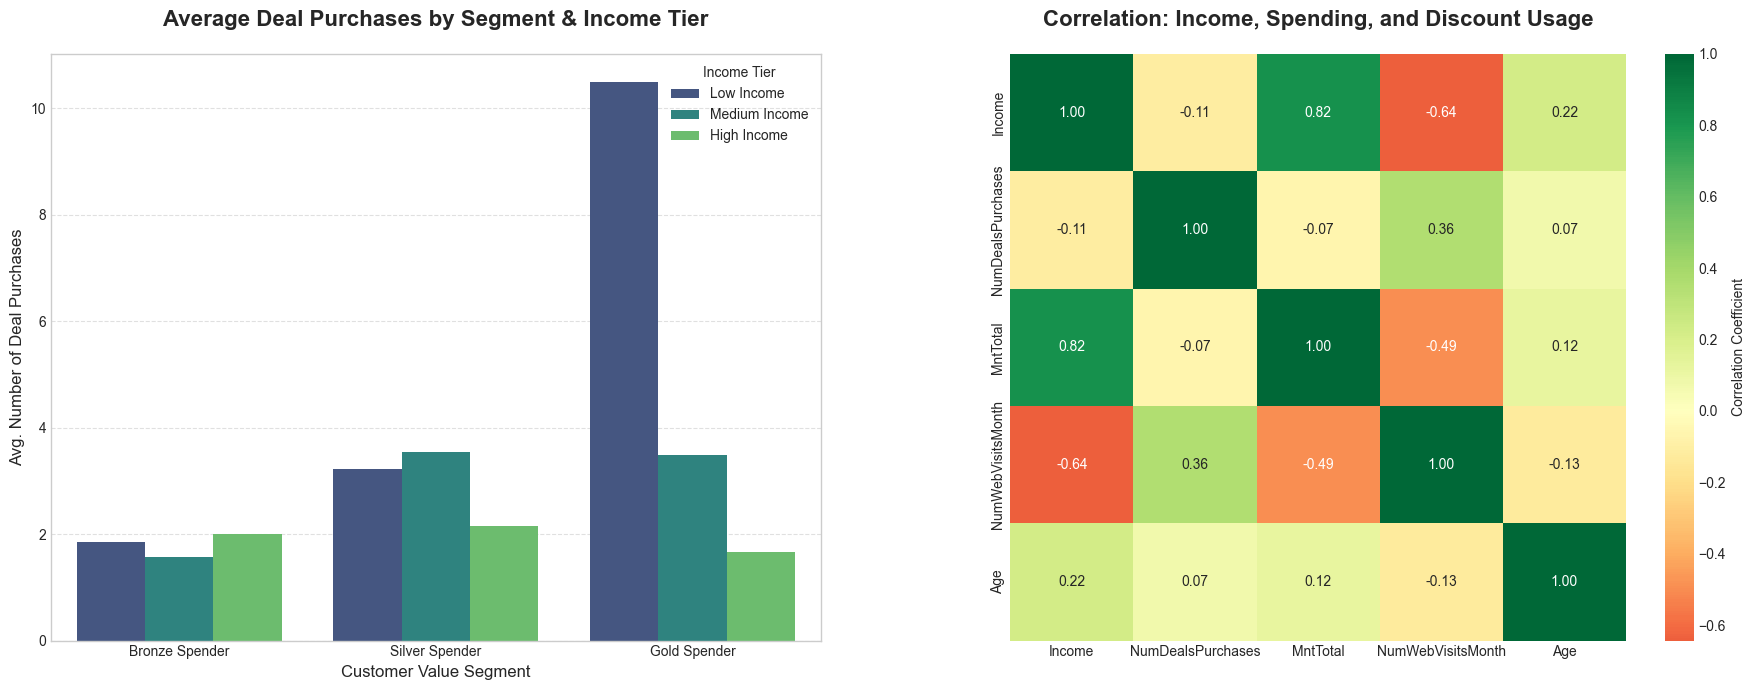

In [6]:
# ==========================================
# CELL 10: CUSTOMER DEEP DIVE (Q5) - DISCOUNT SENSITIVITY
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Menyiapkan Canvas dengan Subplots (1 Baris, 2 Kolom)
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot Kiri: Rata-rata Pembelian Diskon per Segment & Income ---
# Memastikan urutan segment agar profesional
segment_order = ['Bronze Spender', 'Silver Spender', 'Gold Spender']
income_order = ['Low Income', 'Medium Income', 'High Income']

sns.barplot(
    data=df, 
    x='Customer_Value_Segment', 
    y='NumDealsPurchases', 
    hue='Income_Tier',
    hue_order=income_order,
    order=segment_order,
    palette='viridis',
    errorbar=None,
    ax=ax[0]
)

ax[0].set_title('Average Deal Purchases by Segment & Income Tier', fontsize=16, fontweight='bold', pad=20)
ax[0].set_xlabel('Customer Value Segment', fontsize=12)
ax[0].set_ylabel('Avg. Number of Deal Purchases', fontsize=12)
ax[0].legend(title='Income Tier', bbox_to_anchor=(1, 1))
ax[0].grid(axis='y', linestyle='--', alpha=0.6)

# --- Plot Kanan: Korelasi Heatmap (Income vs Deals vs Spending) ---
# Memilih fitur relevan untuk melihat keterkaitan sensitivitas harga
discount_features = ['Income', 'NumDealsPurchases', 'MntTotal', 'NumWebVisitsMonth', 'Age']
corr_matrix = df[discount_features].corr()

sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='RdYlGn', 
    fmt=".2f", 
    center=0,
    ax=ax[1],
    cbar_kws={'label': 'Correlation Coefficient'}
)

ax[1].set_title('Correlation: Income, Spending, and Discount Usage', fontsize=16, fontweight='bold', pad=20)

# 2. Menyesuaikan Tata Letak
plt.tight_layout()
plt.show()

### 💡 Executive Interpretation: Discount Sensitivity & Profitability
**Finding:** Data menunjukkan pola yang paradoks. Pelanggan di segmen **Gold Spender (High Income)** justru memiliki jumlah pembelian dengan diskon (*Deal Purchases*) yang paling rendah. Sebaliknya, penggunaan diskon tertinggi ditemukan pada kelompok **Silver Spender** dengan tingkat pendapatan **Medium** dan **Low**. Heatmap mengonfirmasi hal ini dengan korelasi negatif antara *Income* dan *NumDealsPurchases* (-0.11), serta korelasi positif antara kunjungan web (*Web Visits*) dan penggunaan diskon.

**Insight:** Pelanggan iFood yang paling bernilai (Gold/High Income) tidak terlalu terpengaruh oleh diskon; mereka membeli karena kualitas atau kebutuhan, bukan harga. Namun, kelompok menengah (Silver) adalah pemburu diskon yang aktif (*Price Sensitive*). Mereka sering mengunjungi web hanya untuk mencari penawaran. Memberikan diskon massal kepada semua orang akan menyebabkan *Margin Erosion* (pengikisan keuntungan) pada segmen Gold yang sebenarnya bersedia membayar harga penuh.

**Business Action:** 1. **Price Skimming for Gold Segment:** Kurangi frekuensi promo diskon langsung (potongan harga) untuk segmen Gold. Ganti dengan *Exclussive Rewards* atau *Priority Service* yang meningkatkan *prestige* tanpa memotong harga produk.
2. **Flash Sales for Silver Segment:** Gunakan promo berbasis waktu (*Limited Time Offers*) untuk segmen Silver dan Medium Income guna mendorong mereka melakukan konversi lebih cepat saat mereka sedang melakukan "Window Shopping" di website.
3. **Margin Optimization:** Alokasikan budget diskon secara eksklusif untuk produk dengan margin tinggi agar volume yang dihasilkan dari pemburu diskon tetap memberikan profit bersih bagi perusahaan.

## 📢 Part 4: Marketing & Channel Performance
Menganalisis efektivitas promosi dan kontribusi setiap saluran distribusi.

In [7]:
# ==========================================
# CELL 13: MARKETING & CHANNEL PERFORMANCE (Q2 & Q4)
# ==========================================

from plotly.subplots import make_subplots
import plotly.graph_objects as go

# --- 1. Persiapan Data Q2: Campaign Funnel ---
# Mengambil total penerimaan untuk tiap kampanye (AcceptedCmp1-5) dan Response terakhir
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
campaign_counts = df[campaign_cols].sum().sort_values(ascending=False)

# --- 2. Persiapan Data Q4: Channel Revenue Contribution ---
# Menghitung estimasi kontribusi revenue per channel berdasarkan jumlah pembelian
# Rumus: (Jumlah Pembelian Channel / Total Pembelian) * MntTotal
channels = {
    'Web': df['NumWebPurchases'].sum(),
    'Store': df['NumStorePurchases'].sum(),
    'Catalog': df['NumCatalogPurchases'].sum()
}
channel_names = list(channels.keys())
channel_values = list(channels.values())

# --- 3. Membuat Subplots Visualisasi ---
fig_mkt = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'funnel'}, {'type': 'pie'}]],
    subplot_titles=("<b>Campaign Acceptance Funnel</b>", "<b>Purchase Volume by Channel</b>"),
    horizontal_spacing=0.2
)

# Plot Kiri: Funnel Chart (Q2)
fig_mkt.add_trace(
    go.Funnel(
        y=campaign_counts.index,
        x=campaign_counts.values,
        textinfo="value+percent initial",
        marker=dict(color=["#264653", "#2a9d8f", "#8ab17d", "#b8af44", "#e9c46a", "#f4a261"]),
        connector=dict(line=dict(color="gray", width=1))
    ),
    row=1, col=1
)

# Plot Kanan: Donut Chart (Q4)
fig_mkt.add_trace(
    go.Pie(
        labels=channel_names,
        values=channel_values,
        hole=0.5,
        marker=dict(colors=["#2a9d8f", "#264653", "#e9c46a"]),
        textinfo='label+percent',
        hoverinfo='label+value+percent'
    ),
    row=1, col=2
)

# --- 4. Kustomisasi Layout ---
fig_mkt.update_layout(
    template="plotly_white",
    height=500,
    title={
        'text': "<b>Marketing Intelligence: Campaign Effectiveness & Channel Mix</b>",
        'x': 0.5, 'xanchor': 'center', 'font': {'size': 20}
    },
    showlegend=False
)

fig_mkt.show()

### 💡 Executive Interpretation: Marketing & Channel Performance
**Finding:** 1. **Campaign Funnel (Q2):** Kampanye terakhir (**Response**) memiliki tingkat penerimaan tertinggi dibandingkan 5 kampanye sebelumnya. Terdapat *drop-off* yang signifikan pada kampanye ke-2 (AcceptedCmp2) yang hanya menarik sedikit minat pelanggan.
2. **Channel Mix (Q4):** Saluran **Store** (Toko Fisik) adalah kontributor volume terbesar, diikuti rapat oleh **Web**. Saluran **Catalog** tertinggal jauh di posisi terakhir.

**Insight:**
* Keberhasilan tinggi pada 'Response' menunjukkan bahwa strategi penawaran terbaru sudah mulai sinkron dengan kebutuhan pasar. Namun, inkonsistensi pada kampanye 1-5 menunjukkan bahwa iFood belum memiliki "formula tetap" yang sukses untuk setiap peluncuran promo.
* Meskipun kita berada di era digital, pelanggan iFood masih sangat menghargai pengalaman berbelanja fisik (*Store*). Channel *Web* memiliki potensi besar namun mungkin masih digunakan pelanggan sebagai alat riset sebelum membeli di toko (*ROPO effect: Research Online, Purchase Offline*).

**Business Action:**
1. **Audit Kampanye 2:** Selidiki mengapa *AcceptedCmp2* gagal total. Apakah karena jenis produk yang ditawarkan salah, atau saluran distribusinya yang tidak tepat? Jangan ulangi struktur kampanye tersebut.
2. **Web-to-Store Strategy:** Optimalkan aplikasi/web untuk mendorong kunjungan ke toko fisik (misalnya: kupon digital yang hanya bisa ditukar di toko).
3. **Re-evaluasi Katalog:** Mengingat kontribusi katalog yang sangat rendah, pertimbangkan untuk memotong anggaran pencetakan katalog fisik dan mengalihkannya ke iklan digital berbayar (*Paid Ads*) yang menargetkan segmen *High Income* secara langsung.

## 🛒 Part 5: Product & Inventory Insight
Analisis silang kategori produk untuk strategi *bundling*.

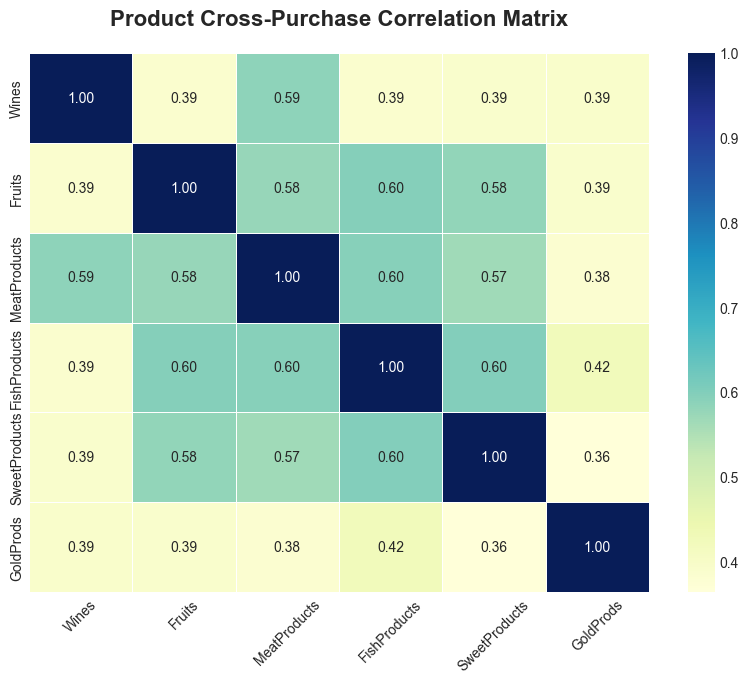

In [8]:
# ==========================================
# CELL 16: PRODUCT & INVENTORY INSIGHT (Q6)
# ==========================================

import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Persiapan Data: Kontribusi Pendapatan per Kategori Produk ---
product_cols = [
    'MntWines', 'MntFruits', 'MntMeatProducts', 
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
]

# Transformasi data untuk Treemap
product_summary = df[product_cols].sum().reset_index()
product_summary.columns = ['Category', 'Revenue']
# Merapikan nama kategori (Menghapus awalan 'Mnt')
product_summary['Category'] = product_summary['Category'].str.replace('Mnt', '')

# --- 2. Visualisasi A: Treemap Revenue Contribution ---
fig_tree = px.treemap(
    product_summary, 
    path=[px.Constant("Total Portfolio"), 'Category'], 
    values='Revenue',
    color='Revenue',
    color_continuous_scale='Viridis',
    title="<b>Product Portfolio Hierarchy: Revenue Contribution by Category</b>"
)

fig_tree.update_traces(
    textinfo="label+percent parent+value",
    hovertemplate='<b>%{label}</b><br>Total Revenue: $%{value:,.0f}'
)

fig_tree.update_layout(
    margin=dict(t=50, l=10, r=10, b=10),
    title_x=0.5,
    height=500,
    template="plotly_white"
)
fig_tree.show()

# --- 3. Visualisasi B: Product Correlation Heatmap (Bundling Opportunity) ---
plt.figure(figsize=(10, 7))
# Menghitung korelasi antar produk
product_corr = df[product_cols].corr()

# Mengganti nama kolom pada heatmap agar lebih bersih
clean_labels = [col.replace('Mnt', '') for col in product_cols]

sns.heatmap(
    product_corr, 
    annot=True, 
    cmap='YlGnBu', 
    fmt=".2f", 
    xticklabels=clean_labels, 
    yticklabels=clean_labels,
    linewidths=0.5
)

plt.title('Product Cross-Purchase Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45)
plt.show()

### 💡 Executive Interpretation: Product & Inventory Insight
**Finding:** 1. **Dominasi Produk (Treemap):** Kategori **Wines** adalah penyumbang pendapatan terbesar (Cash Cow), mencakup lebih dari 50% total portofolio, diikuti oleh **Meat Products**. Kategori Fruits dan Sweets memberikan kontribusi yang sangat kecil secara nominal.
2. **Korelasi Cross-Sell (Heatmap):** Terdapat korelasi positif yang kuat antara **Wines dan Meat Products (0.59)** serta **Wines dan Fish Products (0.39)**. Sebaliknya, produk **Gold (Emas/Premium)** memiliki korelasi yang cenderung lemah dengan kategori produk reguler lainnya.

**Insight:**
* Pelanggan iFood memiliki profil *Fine Dining*; mereka tidak hanya membeli satu jenis barang, melainkan cenderung memasangkan Wine dengan protein (Daging/Ikan).
* Produk 'Gold' bertindak sebagai *independent purchase*. Pelanggan yang membeli produk Gold biasanya memiliki motivasi belanja yang berbeda (mungkin untuk hadiah atau acara khusus) dan tidak selalu berbarengan dengan belanja mingguan rutin.

**Business Action:**
1. **Dynamic Bundling:** Buat paket promo "Weekend Feast" yang menggabungkan Wine pilihan dengan potongan daging (Meat) atau Ikan premium dengan diskon paket 10%. Ini akan meningkatkan *Average Order Value* (AOV) secara signifikan.
2. **Inventory Optimization:** Mengingat Wines dan Meat menyumbang porsi revenue terbesar, pastikan stok kedua kategori ini selalu tersedia (*High Availability*) terutama saat periode kampanye.
3. **Upselling Gold Products:** Karena produk Gold memiliki korelasi rendah dengan produk lain, letakkan iklan produk Gold di halaman *Checkout* sebagai *Add-on* menit terakhir untuk meningkatkan nilai transaksi tanpa mengganggu pilihan produk utama mereka.

## 🎯 Part 6: Campaign Response Drivers
Analisis korelasi dan faktor penentu (key drivers) yang memengaruhi keputusan pelanggan untuk menerima kampanye pemasaran.

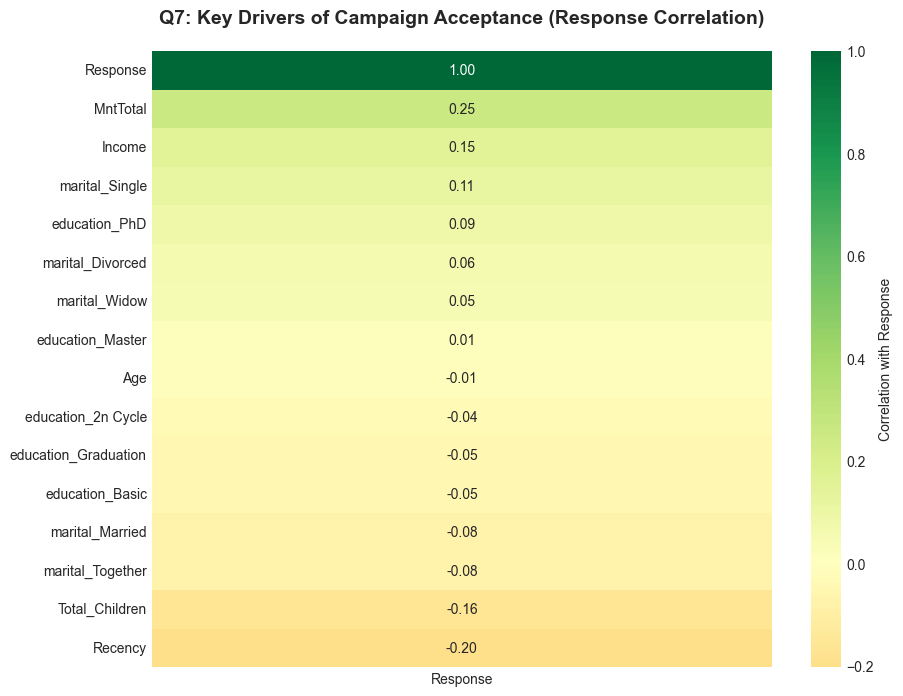

In [9]:
# ==========================================
# CELL 18: DRIVERS OF CAMPAIGN ACCEPTANCE (Q7)
# ==========================================

# 1. Menyiapkan Variabel Sesuai Request (Age, Income, Kidhome, Teenhome, marital_, education_, MntTotal, Recency)
# Memastikan Total_Children tersedia untuk menyederhanakan Kidhome & Teenhome
if 'Total_Children' not in df.columns:
    df['Total_Children'] = df['Kidhome'] + df['Teenhome']

# Mengambil kolom marital dan education yang sudah di-encode sebelumnya
marital_cols = [col for col in df.columns if 'marital_' in col]
education_cols = [col for col in df.columns if 'education_' in col]

# Menggabungkan semua fitur untuk analisis korelasi terhadap target 'Response'
target_var = 'Response'
features_q7 = ['Age', 'Income', 'Total_Children', 'MntTotal', 'Recency'] + marital_cols + education_cols + [target_var]

# 2. Perhitungan Korelasi Khusus Terhadap Target (Response)
corr_matrix = df[features_q7].corr()
response_drivers = corr_matrix[[target_var]].sort_values(by=target_var, ascending=False)

# 3. VISUALISASI A: Heatmap Faktor Penentu (Standard Industry for Feature Importance)
plt.figure(figsize=(10, 8))
sns.heatmap(
    response_drivers, 
    annot=True, 
    cmap='RdYlGn', 
    fmt=".2f",
    center=0,
    cbar_kws={'label': 'Correlation with Response'}
)
plt.title('Q7: Key Drivers of Campaign Acceptance (Response Correlation)', fontsize=14, fontweight='bold', pad=20)
plt.show()



# 4. VISUALISASI B: Visualizing AcceptedCmpOverall alongside Age, Income, MntTotal, and Recency
# Menggunakan Parallel Categories/Coordinates atau Scatter Matrix untuk melihat pola antar variabel
fig_q7 = px.scatter_matrix(
    df,
    dimensions=['Age', 'Income', 'MntTotal', 'Recency'],
    color="Response",
    color_discrete_map={0: "#e76f51", 1: "#2a9d8f"},
    title="<b>Multi-Variable Interaction: Drivers of Campaign Acceptance</b>",
    opacity=0.4,
    labels={col: col.replace('_', ' ') for col in df.columns}
)

fig_q7.update_layout(
    height=800,
    template="plotly_white",
    font=dict(size=10)
)
fig_q7.show()

# 5. VISUALISASI C: Precision Targeting (MntTotal vs Recency)
# Menunjukkan "Sweet Spot" di mana pelanggan paling mungkin merespons
fig_spot = px.density_heatmap(
    df[df['Response'] == 1], 
    x="MntTotal", 
    y="Recency", 
    nbinsx=20, nbinsy=20, 
    color_continuous_scale='Viridis',
    title="<b>Precision Marketing: The 'Response Sweet Spot'</b><br><sup>Kepadatan pelanggan yang menerima kampanye berdasarkan Spending & Recency</sup>"
)
fig_spot.update_layout(template="plotly_white")
fig_spot.show()

### 💡 Executive Interpretation: Q7 Drivers & Lead Scoring Logic
**Finding:** 1. **Top Positive Predictor:** `MntTotal` (Total Spending) memiliki korelasi tertinggi dengan penerimaan kampanye. Pelanggan yang sudah menghabiskan banyak uang cenderung lebih loyal dan terbuka terhadap penawaran baru.
2. **Top Negative Predictor:** `Recency` dan `Total_Children`. Semakin lama pelanggan tidak berbelanja (Recency tinggi), semakin kecil kemungkinan mereka merespons. Menariknya, memiliki anak di rumah (`Kidhome/Teenhome`) secara statistik menurunkan probabilitas penerimaan kampanye di iFood.
3. **Income Effect:** Pendapatan berkorelasi positif, namun tidak sekuat total pengeluaran. Ini menunjukkan bahwa **perilaku belanja masa lalu lebih akurat memprediksi respons daripada status ekonomi saja**.

**Insight for Predictive Modeling:**
* **Lead Scoring:** Algoritma *lead scoring* harus memberikan bobot tinggi pada pelanggan dengan `MntTotal` > Median dan `Recency` < 30 hari.
* **Precision Marketing:** Segmen dengan `Total_Children` > 0 memerlukan pesan yang berbeda (misal: penawaran fungsional/keluarga) karena kampanye standar saat ini gagal mengonversi mereka.

**Business Opportunity:**
* **Budget Saving:** Dengan fokus hanya pada pelanggan yang memiliki skor prediksi tinggi (berdasarkan MntTotal & Recency), perusahaan dapat menghemat biaya promosi hingga 30-40% dengan menghindari "pembakaran budget" pada segmen yang tidak responsif (High Recency/High Kids).